<a href="https://colab.research.google.com/github/EvalynTheAnalyst/facial_recognition_analysis/blob/evalyn/human_emotion_detection6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project Title: Facial Emotion Recognition for Mental Wellness Monitoring
### Goal:
 Build and deploy a system that detects human emotions (e.g. happy, sad, angry, neutral) from facial images to help mental health apps understand users’ emotional states in real time.

### Why this matters:
 Emotional monitoring can help improve chatbot responses, tailor wellness content, and alert when users show signs of distress.


#DATA COLLECTION AND ANOTATION


In [1]:
# install icrawler
!pip install -q icrawler

# Copying images to my drive

In [2]:
# Install if running in Colab
!pip install -q icrawler opencv-python-headless

from icrawler.builtin import GoogleImageCrawler
import os
import glob
import cv2
import shutil
import random
import re

# Step 1: Generate Queries
def generate_search_queries():
    expressions = ["happy", "sad", "angry", "neutral", "surprised", "disgusted"]
    descriptors = [
        "Black woman", "Black man", "Black boy", "Black girl", "Black toddler", "Black elderly man", "Black elderly woman",
        "White woman", "White man", "White boy", "White girl", "White toddler", "White elderly man", "White elderly woman",
        "Middle Eastern woman", "Middle Eastern man", "Middle Eastern boy", "Middle Eastern girl", "Middle Eastern toddler", "Middle Eastern elderly man", "Middle Eastern elderly woman",
        "Asian woman", "Asian man", "Asian toddler","Asian girl", "Asian elderly man", "Asian elderly woman",
        "Indian woman", "Indian man", "Indian boy", "Indian girl", "Indian toddler", "Indian elderly man", "Indian elderly woman",
        "mixed race people",
    ]

    queries = []
    for expr in expressions:
        for desc in descriptors:
            q = f"{expr} {desc} face photo"
            queries.append(q)
    return queries

# Step 2: Collect Images
def collect_images_by_keywords(base_dir="faces", keyword_list=[], max_images=500):
    for keyword in keyword_list:
        folder_name = keyword.replace(" ", "_").replace(",", "").lower()
        output_path = os.path.join(base_dir, folder_name)
        os.makedirs(output_path, exist_ok=True)

        print(f"🔍 Downloading: {keyword}")
        crawler = GoogleImageCrawler(storage={'root_dir': output_path})
        crawler.crawl(keyword=keyword, max_num=max_images, filters={'size': 'medium', 'type': 'photo'})

# Step 3: Remove Known Bad Folders
def delete_folder(folder_path):
    shutil.rmtree(folder_path, ignore_errors=True)
    print(f"🗑️ Removed: {folder_path}")

def remove_known_bad_folders(base_dir="faces", folder_names=[]):
    for folder_name in folder_names:
        folder_path = os.path.join(base_dir, folder_name)
        delete_folder(folder_path)

# Step 4: Remove Images Without Faces
def clean_images_without_faces(base_dir="faces"):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    cleaned = 0
    removed = 0

    print("\n Cleaning images without faces...")
    for path in glob.glob(f"{base_dir}/**/*.jpg", recursive=True):
        img = cv2.imread(path)
        if img is None:
            continue
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)

        if len(faces) == 0:
            print(f"No face: {path}")
            os.remove(path)
            removed += 1
        else:
            cleaned += 1

    print(f"Cleanup complete: {cleaned} kept, {removed} removed.\n")

# Step 5: Add Blurred Face Variants
def blur_random_faces(base_dir="faces", blur_ratio=0.1):
    print(f"Blurring ~{int(blur_ratio*100)}% of images...")
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    all_images = glob.glob(f"{base_dir}/**/*.jpg", recursive=True)
    selected_images = random.sample(all_images, int(len(all_images) * blur_ratio))

    for path in selected_images:
        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.1, 4)

        if len(faces) > 0:
            for (x, y, w, h) in faces:
                face_region = img[y:y+h, x:x+w]
                face_region = cv2.GaussianBlur(face_region, (31, 31), 30)
                img[y:y+h, x:x+w] = face_region
        else:
            img = cv2.GaussianBlur(img, (15, 15), 15)

        new_path = path.replace(".jpg", "_blurred.jpg")
        cv2.imwrite(new_path, img)

    print(f" Blurred {len(selected_images)} images.\n")

# Step 6: Organize for ML Training
def organize_for_ml(source_dir="faces", output_dir="dataset"):
    print(f"\n Organizing into '{output_dir}/'...")
    os.makedirs(output_dir, exist_ok=True)

    folders = [f for f in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, f))]
    for folder in folders:
        match = re.match(r"^(happy|sad|angry|neutral|surprised|disgusted)", folder)
        if not match:
            print(f"Skipping unknown: {folder}")
            continue

        label = match.group(1)
        label_dir = os.path.join(output_dir, label)
        os.makedirs(label_dir, exist_ok=True)

        image_paths = glob.glob(os.path.join(source_dir, folder, "*.jpg"))
        for img_path in image_paths:
            fname = os.path.basename(img_path)
            dest = os.path.join(label_dir, f"{folder}_{fname}")
            shutil.copyfile(img_path, dest)

    print(" Dataset organized!\n")

# Step 7: Split dataset into train/val/test
def split_dataset_for_ml(input_dir="dataset", output_dir="final_dataset", train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    print(f"\nSplitting dataset into train/val/test...")
    assert abs((train_ratio + val_ratio + test_ratio) - 1.0) < 1e-6, "Ratios must sum to 1"

    splits = ["train", "val", "test"]
    for split in splits:
        for label in os.listdir(input_dir):
            src_label_dir = os.path.join(input_dir, label)
            if not os.path.isdir(src_label_dir):
                continue
            dst_dir = os.path.join(output_dir, split, label)
            os.makedirs(dst_dir, exist_ok=True)

    for label in os.listdir(input_dir):
        src_label_dir = os.path.join(input_dir, label)
        if not os.path.isdir(src_label_dir):
            continue

        images = glob.glob(os.path.join(src_label_dir, "*.jpg"))
        random.shuffle(images)
        total = len(images)
        n_train = int(total * train_ratio)
        n_val = int(total * val_ratio)

        split_lists = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for split, split_images in split_lists.items():
            dst_dir = os.path.join(output_dir, split, label)
            for img_path in split_images:
                fname = os.path.basename(img_path)
                shutil.copyfile(img_path, os.path.join(dst_dir, fname))

    print("Dataset split complete!\n")

# # Pipeline Runner
# if __name__ == "__main__":
#     base_dir = "faces"
#     queries = generate_search_queries()

#     # Step 1: Download
#     collect_images_by_keywords(base_dir=base_dir, keyword_list=queries, max_images=10)

#     # Step 2: Clean known bad folders
#     remove_known_bad_folders(base_dir=base_dir, folder_names=["blurry_happy_face_picture"])

#     # Step 3: Remove images without faces
#     clean_images_without_faces(base_dir=base_dir)

#     # # Step 4: Add blurred variants
#     #blur_random_faces(base_dir=base_dir, blur_ratio=0.1)

#     # Step 5: Organize for ML training
#     organize_for_ml(source_dir=base_dir, output_dir="dataset")

#     # Step 6: Split into train/val/test
#     split_dataset_for_ml(input_dir="dataset", output_dir="final_dataset", train_ratio=0.7, val_ratio=0.15, test_ratio=0.15)

#     print("🎉 All done!")


## Save into drive

In [3]:
# # copy images to my drive
import shutil

# # Create a directory in your Google Drive
!mkdir -p /content/drive/MyDrive

# # Copy the  folder
# shutil.copytree("final_dataset", "/content/drive/MyDrive/face_data", dirs_exist_ok=True)


In [4]:
!cp -r /content/dataset /content/drive/MyDrive/face_data/facial_dataset

cp: cannot stat '/content/dataset': No such file or directory


In [5]:
!ls /content/drive/MyDrive/facial_dataset/


ls: cannot access '/content/drive/MyDrive/facial_dataset/': No such file or directory


## Data Preprocessing & Augmentation

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam,SGD
from sklearn.model_selection import StratifiedKFold
import os
import shutil
import matplotlib.pyplot as plt
import numpy as np
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report
import seaborn as sns

In [7]:
from google.colab import drive
import os

# Remove existing files in the mountpoint if any
mountpoint = '/content/drive'
if os.path.exists(mountpoint) and os.path.isdir(mountpoint):
    for item in os.listdir(mountpoint):
        item_path = os.path.join(mountpoint, item)
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.unlink(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)

drive.mount(mountpoint)

Mounted at /content/drive


In [37]:
#count images per class
import os
from collections import defaultdict

#Dataset path
base_path = "/content/drive/MyDrive/face_data"

#Dictionary to store counts per split and per emotion
split_counts = {
    'train': defaultdict(int),
    'val': defaultdict(int),
    'test': defaultdict(int)
}

#Loop through each split
for split in split_counts.keys():
    split_path = os.path.join(base_path, split)
    if not os.path.exists(split_path):
        continue
    for emotion in os.listdir(split_path):
        emotion_path = os.path.join(split_path, emotion)
        if os.path.isdir(emotion_path):
            count = len([
                f for f in os.listdir(emotion_path)
                if os.path.isfile(os.path.join(emotion_path, f)) and f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
            split_counts[split][emotion] = count

#Display results
total_all = 0
print("Image Count Breakdown Per Split and Class:\n")
for split in ['train', 'val', 'test']:
    print(f"🔹 {split.upper()} SPLIT")
    total_split = 0
    for emotion, count in split_counts[split].items():
        print(f"{emotion}: {count} images")
        total_split += count
    total_all += total_split
    print(f"Total in {split}: {total_split} images\n")

print(f"Grand Total Across All Splits: {total_all} images")
#

Image Count Breakdown Per Split and Class:

🔹 TRAIN SPLIT
neutral: 143 images
angry: 185 images
happy: 215 images
surprised: 177 images
sad: 126 images
disgusted: 147 images
Total in train: 993 images

🔹 VAL SPLIT
happy: 45 images
angry: 42 images
neutral: 35 images
disgusted: 36 images
surprised: 43 images
sad: 33 images
Total in val: 234 images

🔹 TEST SPLIT
disgusted: 40 images
neutral: 37 images
sad: 35 images
happy: 51 images
angry: 44 images
surprised: 42 images
Total in test: 249 images

Grand Total Across All Splits: 1476 images


In [28]:
train_path = '/content/drive/MyDrive/face_data/train'




In [30]:
test_path = '/content/drive/MyDrive/face_data/test'




In [31]:
val_path = '/content/drive/MyDrive/face_data/val'


In [22]:
#2. Data Preprocessing & Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,            # slightly higher rotation
    width_shift_range=0.15,       # shift up to 15%
    height_shift_range=0.15,      # shift up to 15%
    zoom_range=0.2,               # zoom in/out up to 20%
    shear_range=10,               # slight shear
    horizontal_flip=True,
    fill_mode='nearest'           # avoid empty pixels after transform
)

In [32]:
test_datagen = ImageDataGenerator(
    rescale =1./255)

In [33]:
val_datagen = ImageDataGenerator(
    rescale =1./255,
    )

In [34]:
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size =(224,224),
    batch_size = 32,
    class_mode = 'sparse',
    shuffle = True
)

Found 993 images belonging to 6 classes.


In [35]:
val_data = val_datagen.flow_from_directory(
    val_path,
    target_size =(224,224),
    batch_size = 32,
    class_mode = 'sparse',
    shuffle = True
)

Found 234 images belonging to 6 classes.


In [36]:
test_data = test_datagen.flow_from_directory(
    test_path,
    target_size =(224,224),
    batch_size = 32,
    class_mode = 'sparse'
)

Found 249 images belonging to 6 classes.


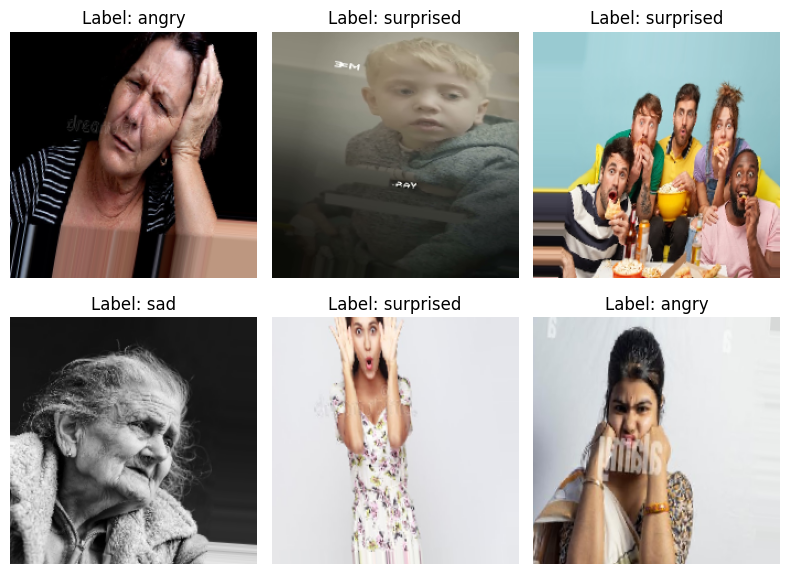

In [38]:
#first 6 image
image, label = next(train_data)
class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(8,6))
for i in range(6):
   plt.subplot(2, 3, i+1)
   plt.imshow(image[i])
   label_index = int(label[i])  # directly use integer label
   plt.title(f"Label: {class_names[label_index]}")
   plt.axis("off")
plt.tight_layout()
plt.show()

## modelcompile



In [40]:
from tensorflow.keras.applications import MobileNetV2,ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

base =ResNet50V2(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(6, activation='softmax')(x)

model = Model(inputs=base.input, outputs=output)

# Unfreeze last 20 layers for fine-tuning
for layer in base.layers[:-20]:
    layer.trainable = False
for layer in base.layers[-20:]:
    layer.trainable = True

optimizer = Adam(learning_rate=1e-4)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', min_delta = 0,verbose = 1, patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_delta=0.0001),
    ModelCheckpoint('best_model.h5', save_best_only=True)]

history = model.fit(train_data, validation_data=val_data, epochs=50,callbacks=callbacks)

loss, acc = model.evaluate(test_data)
print(f"Test Accuracy: {acc}")

pred = model.predict(test_data)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2146 - loss: 1.8199

32/32 ━━━━━━━━━━━━━━━━━━━━ 374s 11s/step - accuracy: 0.2159 - loss: 1.8179 - val_accuracy: 0.2436 - val_loss: 1.7595 - learning_rate: 1.0000e-04
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.4816 - loss: 1.4741

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 630ms/step - accuracy: 0.4809 - loss: 1.4736 - val_accuracy: 0.3205 - val_loss: 1.7182 - learning_rate: 1.0000e-04
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 582ms/step - accuracy: 0.5601 - loss: 1.2244 - val_accuracy: 0.3248 - val_loss: 1.9483 - learning_rate: 1.0000e-04
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.6450 - loss: 1.0146

32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 627ms/step - accuracy: 0.6446 - loss: 1.0147 - val_accuracy: 0.4402 - val_loss: 1.7007 - learning_rate: 1.0000e-04
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 578ms/step - accuracy: 0.6852 - loss: 0.9127 - val_accuracy: 0.4573 - val_loss: 1.7712 - learning_rate: 1.0000e-04
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 609ms/step - accuracy: 0.7608 - loss: 0.7528 - val_accuracy: 0.4615 - val_loss: 1.8805 - learning_rate: 1.0000e-04
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 572ms/step - accuracy: 0.8224 - loss: 0.5612 - val_accuracy: 0.4786 - val_loss: 1.9986 - learning_rate: 1.0000e-04
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 575ms/step - accuracy: 0.8486 - loss: 0.4768 - val_accuracy: 0.4829 - val_loss: 1.8932 - learning_rate: 2.0000e-05
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 625ms/step - accuracy: 0.8584 - loss: 0.4529 - val_accuracy: 0.4957 - val_loss: 1.8436 - learning_rate: 2.0000e-05
Epoch 9: early stopping
Restoring model weights from the end of the b

In [41]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 40,998,804 (156.40 MB)

 Trainable params: 8,437,894 (32.19 MB)

 Non-trainable params: 15,685,120 (59.83 MB)

 Optimizer params: 16,875,790 (64.38 MB)

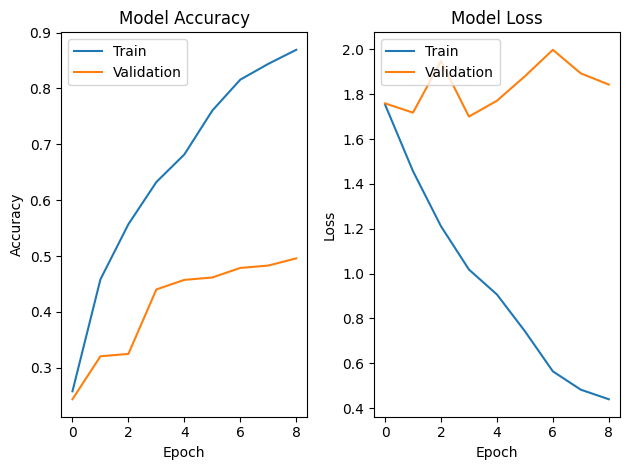

In [42]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

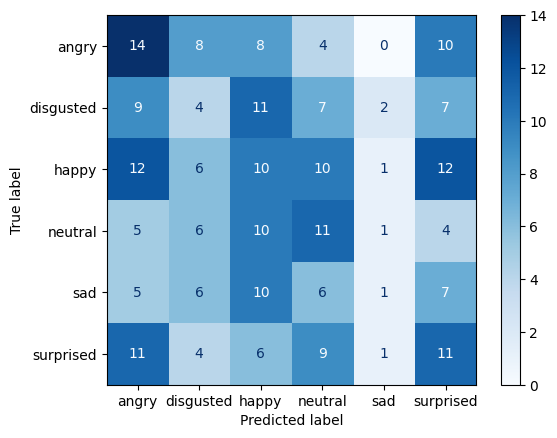

In [43]:
cm = confusion_matrix(test_data.classes, np.argmax(pred,axis=1))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_data.class_indices)
display.plot(cmap=plt.cm.Blues)
plt.show()

In [44]:
print(classification_report(test_data.classes,np.argmax(pred,axis=1)))

              precision    recall  f1-score   support

           0       0.25      0.32      0.28        44
           1       0.12      0.10      0.11        40
           2       0.18      0.20      0.19        51
           3       0.23      0.30      0.26        37
           4       0.17      0.03      0.05        35
           5       0.22      0.26      0.24        42

    accuracy                           0.20       249
   macro avg       0.19      0.20      0.19       249
weighted avg       0.19      0.20      0.19       249



In [48]:
model.save('model.h5')

In [2]:
from PIL import Image
import tensorflow as tf
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator,img_to_array
import os

MODEL_PATH = os.path.join("model","/content/model.h5")
CLASS_NAME = ['angry', 'sad', 'happy','disgust', 'surprise', 'neutral']

model = tf.keras.models.load_model(MODEL_PATH)


def predict_emotion(image:Image,face_detect=True):
  if image is None:
    return {"label": "No image", "confidence": 0.0}

    # Convert to RGB, resize, normalize, and reshape for model
  img = image.convert("RGB").resize((224, 224))
  img_array = img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  preds = model.predict(img_array)
  idx = int(np.argmax(preds, axis = 1)[0])
  label = CLASS_NAME[idx]
  confidence = float(np.max(preds))

  return f"Label: {label} \n \n Confidence: {round(confidence,4)}"


  #Creating the theme
theme = gr.themes.Soft(
    primary_hue="indigo",
    secondary_hue="rose",
    neutral_hue="gray",
    font=["Helvetica", "ui-sans-serif", "system-ui"],
)

  #user interface
demo = gr.Interface(
      fn = predict_emotion,
      inputs = [
          gr.Image(type = 'pil',label = 'Upload a face Image', image_mode='RGB'),
          gr.Checkbox(label = 'Run face and crop', value=True)
      ],
      outputs=[
          gr.Label(num_top_classes=1,label ="Predicted emotions and Confidence")

      ],
      title='Emotion Detector',
      description=(
          "<div style='text-align:center'>"
        "<h3>Upload a photo and let the AI detect the emotion!</h3>"
        "<p>Emotions: angry, disgust, fear, happy, neutral, sad, surprise.</p>"
        "</div>"
      ),
      theme = theme,
      allow_flagging="never",
      live = True,

  )

if __name__ == "__main__":
    demo.launch(debug=True)






/usr/local/lib/python3.11/dist-packages/gradio/interface.py:425: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://20bc5ffdc8f9a9e6cd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gradio/queueing.py", line 626, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/route_utils.py", line 350, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 2250, in process_api
    data = await self.postprocess_data(block_fn, result["prediction"], state)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 2028, in postprocess_data
    prediction_value = block.postprocess(prediction_value)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/components/label.py", line 143, in postprocess

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/gradio/queueing.py", line 626, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/route_utils.py", line 350, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 2250, in process_api
    data = await self.postprocess_data(block_fn, result["prediction"], state)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/blocks.py", line 2028, in postprocess_data
    prediction_value = block.postprocess(prediction_value)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/gradio/components/label.py", line 143, in postprocess

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://20bc5ffdc8f9a9e6cd.gradio.live
